# Step 0. Study area context map

This notebook holds the study-area context figure that was split out of the main visualization notebook.

It uses the same centralized result discovery and plot terminology as the main dashboard notebook.

In [6]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import contextily as ctx
    HAS_CONTEXTILY = True
except ImportError:
    HAS_CONTEXTILY = False

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

plt.style.use("default")


def _first_existing(paths):
    for path in paths:
        if path and Path(path).exists():
            return Path(path)
    return None


home = Path.home()
results_candidates = []
if os.getenv("NIRD_RESULTS_ROOT"):
    results_candidates.append(Path(os.getenv("NIRD_RESULTS_ROOT")))
results_candidates.extend([
    home / "NIRD_Data" / "results",
    repo_root / "results",
    repo_root / "sandbox" / "results",
])
results_root = _first_existing(results_candidates)
if results_root is None:
    raise FileNotFoundError("Could not locate a results root. Set NIRD_RESULTS_ROOT.")

input_candidates = []
if os.getenv("NIRD_INPUT_ROOT"):
    input_candidates.append(Path(os.getenv("NIRD_INPUT_ROOT")))
input_candidates.extend([
    home / "NIRD_Data" / "va_soge_clusters_toy",
    home / "NIRD_Data" / "fairfax_soge_clusters_toy",
    repo_root / "sandbox" / "fairfax_soge_clusters_toy",
    repo_root / "sandbox" / "fairfax_baseline",
])
input_root = _first_existing(input_candidates)
if input_root is None:
    raise FileNotFoundError("Could not locate an input root. Set NIRD_INPUT_ROOT.")

variant_env = os.getenv("NIRD_RESULTS_VARIANT")
variant_candidates = sorted([p.name for p in (results_root / "base_scenario").glob("*") if p.is_dir()]) if (results_root / "base_scenario").exists() else []
if variant_env and (results_root / "base_scenario" / variant_env).exists():
    VARIANT = variant_env
elif "revision" in variant_candidates:
    VARIANT = "revision"
elif "od_inflation_100x" in variant_candidates:
    VARIANT = "od_inflation_100x"
elif len(variant_candidates) == 1:
    VARIANT = variant_candidates[0]
elif variant_candidates:
    VARIANT = variant_candidates[0]
else:
    VARIANT = variant_env or "revision"

def _available_depth_keys(variant: str) -> list[int]:
    disruption_root = results_root / "disruption_analysis" / variant
    if not disruption_root.exists():
        return []
    depth_keys = []
    for p in disruption_root.iterdir():
        if p.is_dir() and p.name.isdigit():
            depth_keys.append(int(p.name))
    return sorted(set(depth_keys))


def _available_flood_ids(variant: str, depth_key: int) -> list[int]:
    links_dir = results_root / "disruption_analysis" / variant / str(depth_key) / "links"
    if not links_dir.exists():
        return []
    flood_ids = []
    for p in links_dir.glob("road_links_*.gpq"):
        tail = p.stem.split("_")[-1]
        if tail.isdigit():
            flood_ids.append(int(tail))
    return sorted(set(flood_ids))


depth_candidates = _available_depth_keys(VARIANT)
if 15 in depth_candidates:
    DEPTH_KEY = 15
elif 30 in depth_candidates:
    DEPTH_KEY = 30
elif depth_candidates:
    DEPTH_KEY = depth_candidates[0]
else:
    DEPTH_KEY = 30

flood_candidates = _available_flood_ids(VARIANT, DEPTH_KEY)
if 1 in flood_candidates:
    FLOOD_KEY = 1
elif flood_candidates:
    FLOOD_KEY = flood_candidates[0]
else:
    FLOOD_KEY = 1

STUDY_AREA_LABEL = "Virginia"
HAZARD_TYPE_LABEL = "Flood"
SCENARIO_LABEL = "Reference context"

fig_root = results_root / "figures" / VARIANT
study_fig_dir = fig_root / "step0_study_area"
study_fig_dir.mkdir(parents=True, exist_ok=True)


def save_figure(fig: plt.Figure, out_dir: Path, stem: str) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{stem}.png", dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(out_dir / f"{stem}.pdf", bbox_inches="tight", facecolor="white")

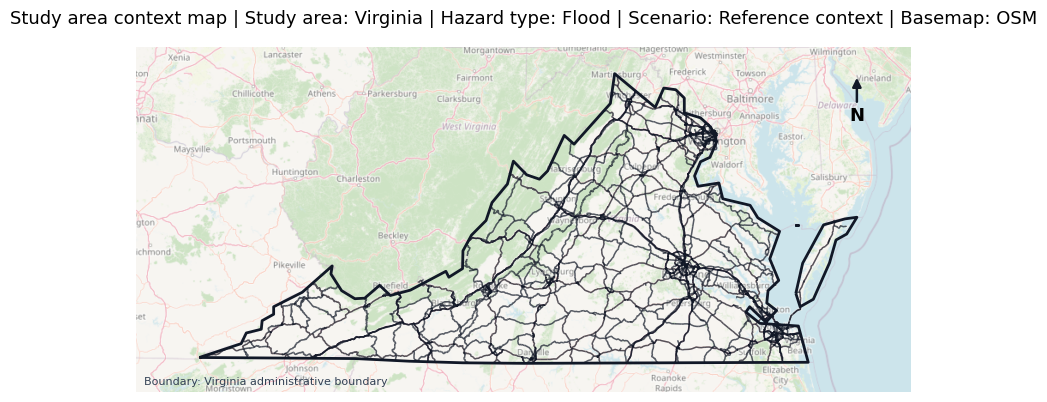

In [9]:
# Study area basemap (context only) -- prefer OSM tiles
from shapely.geometry import box
import requests

edge_flows = gpd.read_parquet(results_root / "base_scenario" / VARIANT / "edge_flows.gpq")
study_area = edge_flows[["geometry"]].copy()
if study_area.crs is None:
    study_area = study_area.set_crs("EPSG:4326")

study_area_3857 = study_area.to_crs("EPSG:3857")
footprint = study_area_3857.geometry.union_all().convex_hull if hasattr(study_area_3857.geometry, "union_all") else study_area_3857.unary_union.convex_hull
minx, miny, maxx, maxy = footprint.bounds
pad_x = (maxx - minx) * 0.10 if maxx > minx else 1000
pad_y = (maxy - miny) * 0.10 if maxy > miny else 1000
xlim = (minx - pad_x, maxx + pad_x)
ylim = (miny - pad_y, maxy + pad_y)

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#e5e7eb")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal")

basemap_label = "OSM"
osm_error = None
if HAS_CONTEXTILY:
    try:
        ctx.add_basemap(
            ax,
            source=ctx.providers.OpenStreetMap.Mapnik,
            zoom="auto",
            attribution=False,
            alpha=0.6,
        )
    except Exception as e:
        osm_error = str(e)
        basemap_label = "OSM unavailable; showing vector fallback"
else:
    basemap_label = "contextily unavailable; showing vector fallback"

study_area_3857.plot(ax=ax, linewidth=1.1, color="#111827", alpha=0.7, zorder=4)


def _load_va_boundary() -> gpd.GeoDataFrame | None:
    local_candidates = [
        input_root / "study_area" / "va_study_area.geojson",
        input_root / "study_area" / "va_study_area.gpkg",
        input_root / "study_area" / "va_boundary.geojson",
        input_root / "study_area" / "va_boundary.gpkg",
        input_root / "study_area" / "virginia_boundary.geojson",
        input_root / "study_area" / "virginia_boundary.gpkg",
        input_root / "study_area" / "virginia_study_area.geojson",
        input_root / "study_area" / "virginia_study_area.gpkg",
        input_root / "study_area" / "state_boundary.geojson",
        input_root / "study_area" / "state_boundary.gpkg",
    ]
    for candidate in local_candidates:
        if candidate.exists():
            try:
                boundary = gpd.read_file(candidate).to_crs("EPSG:3857")
                if len(boundary) > 0:
                    return boundary
            except Exception:
                continue

    remote_urls = [
        "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json",
        "https://raw.githubusercontent.com/johan/world.geo.json/master/countries/USA/VA.geo.json",
    ]
    for url in remote_urls:
        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            data = response.json()
            if isinstance(data, dict) and data.get("type") == "FeatureCollection":
                features = data.get("features", [])
            elif isinstance(data, dict) and data.get("type") == "Feature":
                features = [data]
            else:
                features = []
            boundary = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
            if "name" in boundary.columns:
                boundary = boundary[boundary["name"].astype(str).str.lower() == "virginia"].copy()
            elif "id" in boundary.columns:
                boundary = boundary[boundary["id"].astype(str).str.lower().isin(["va", "virginia"])].copy()
            if len(boundary) > 0:
                return boundary.to_crs("EPSG:3857")
        except Exception:
            continue

    return None


admin_boundary = None
admin_label = "study area bounding box"
if os.getenv("NIRD_CONTEXT_BOUNDARY_MODE", "admin").strip().lower() != "bbox":
    admin_boundary = _load_va_boundary()
    if admin_boundary is not None:
        admin_label = "Virginia administrative boundary"

if admin_boundary is not None:
    admin_boundary.boundary.plot(ax=ax, color="#111827", linewidth=2.0, zorder=5)
else:
    bbox_geom = gpd.GeoSeries([box(*footprint.bounds)], crs=study_area_3857.crs)
    bbox_geom.boundary.plot(ax=ax, color="#111827", linewidth=1.8, linestyle="--", zorder=5)

ax.annotate(
    "N",
    xy=(0.93, 0.92),
    xytext=(0.93, 0.80),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold",
    arrowprops=dict(arrowstyle="-|>", color="#111827", lw=1.8),
)

ax.set_title(
    f"Study area context map | Study area: {STUDY_AREA_LABEL} | Hazard type: {HAZARD_TYPE_LABEL} | Scenario: {SCENARIO_LABEL} | Basemap: {basemap_label}",
    fontsize=13,
)
ax.text(0.01, 0.02, f"Boundary: {admin_label}", transform=ax.transAxes, fontsize=8, color="#334155")
if osm_error:
    ax.text(0.01, 0.06, f"OSM error: {osm_error[:120]}", transform=ax.transAxes, fontsize=7, color="#334155")
ax.set_axis_off()

save_figure(fig, study_fig_dir, "step0_study_area_basemap")
plt.show()

## Step 0. Major model input tables and parameter diagnostics

This section visualizes key inputs used by damage and recovery workflows:

- `recovery design_updated.csv` (bridge/road recovery curves)
- `damage_ratio_road_flood.xlsx` (damage ratio curves by flood intensity)
- `damage_cost_road_flood.xlsx` (asset cost assumptions)
- parameter JSON files in `parameters/`

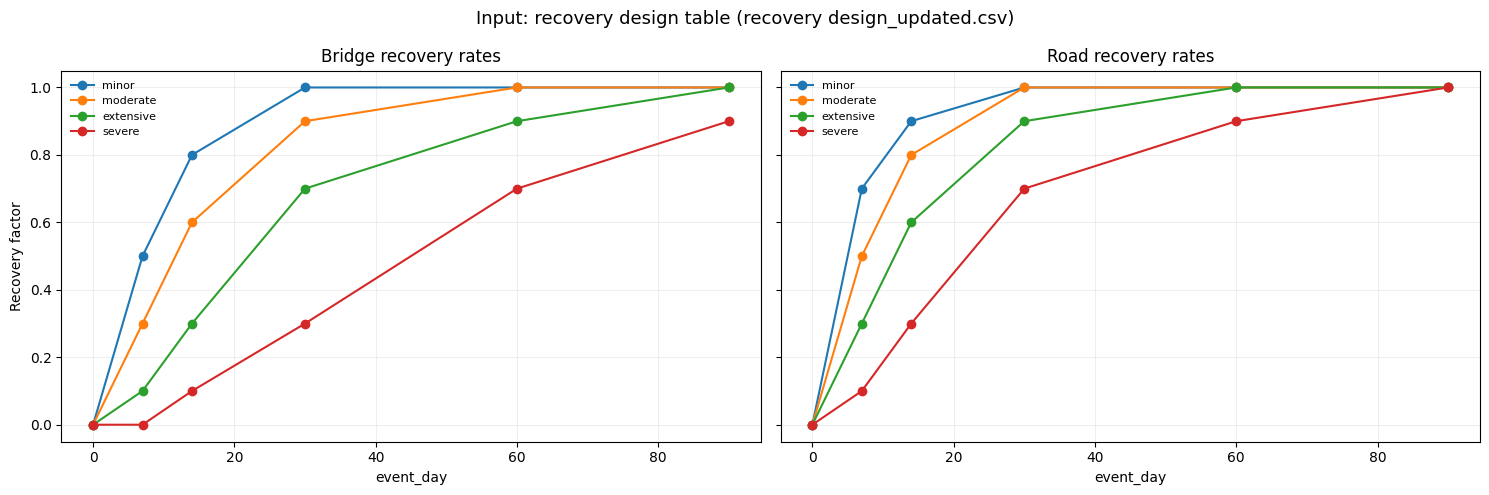

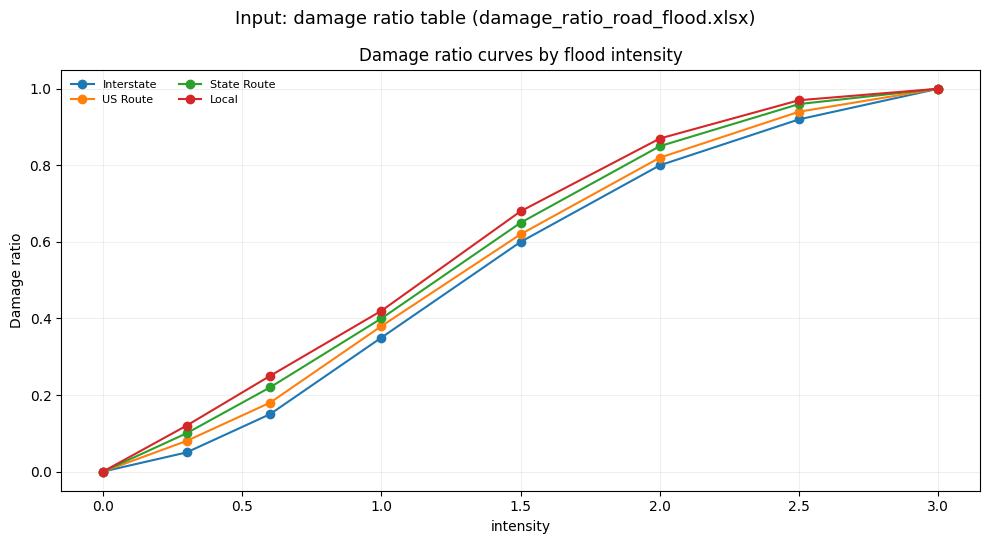

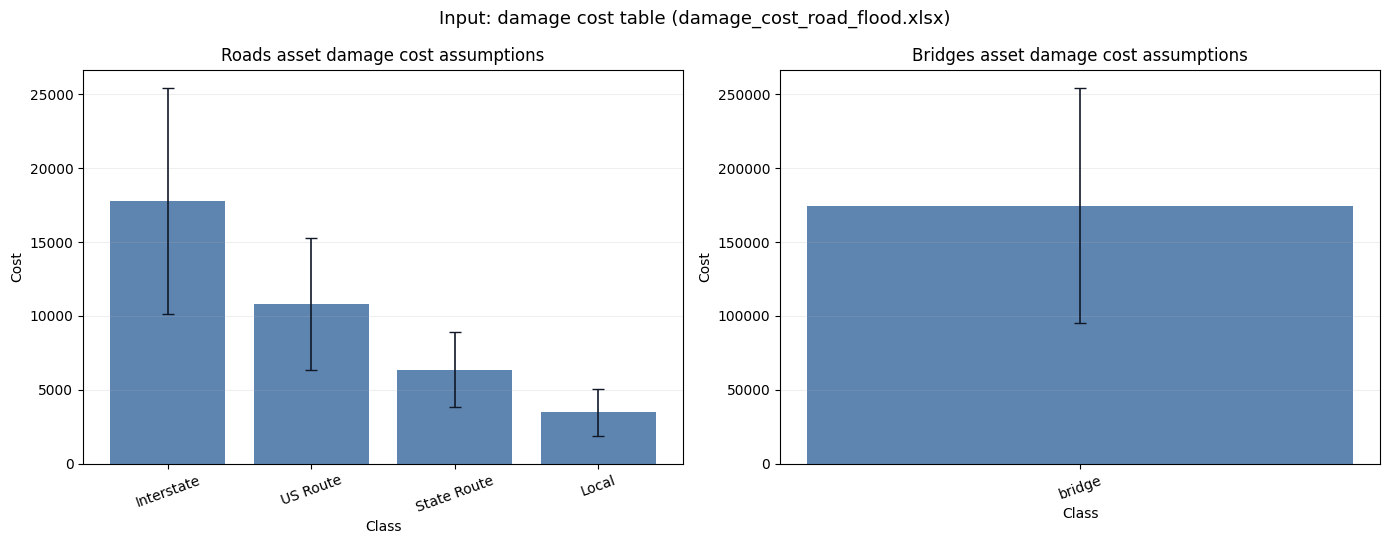

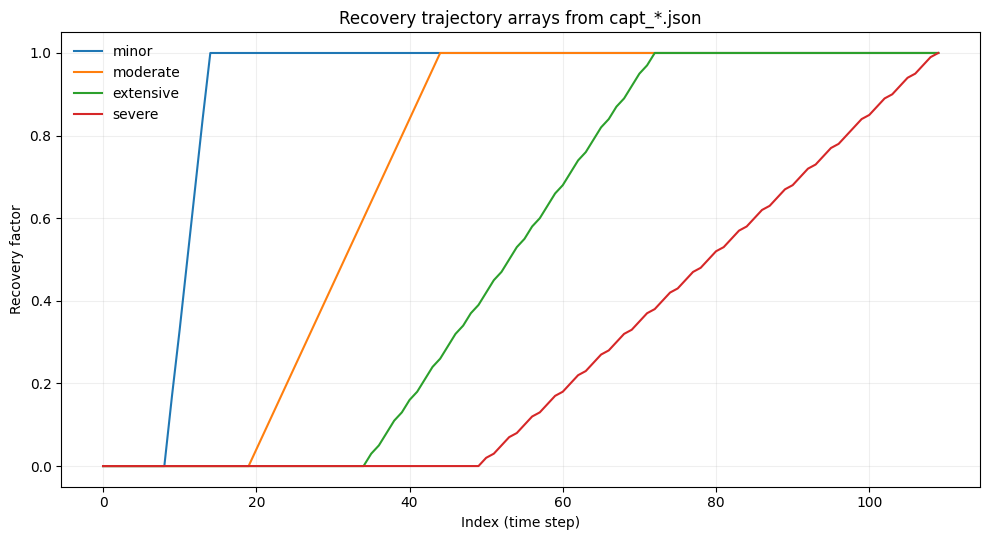

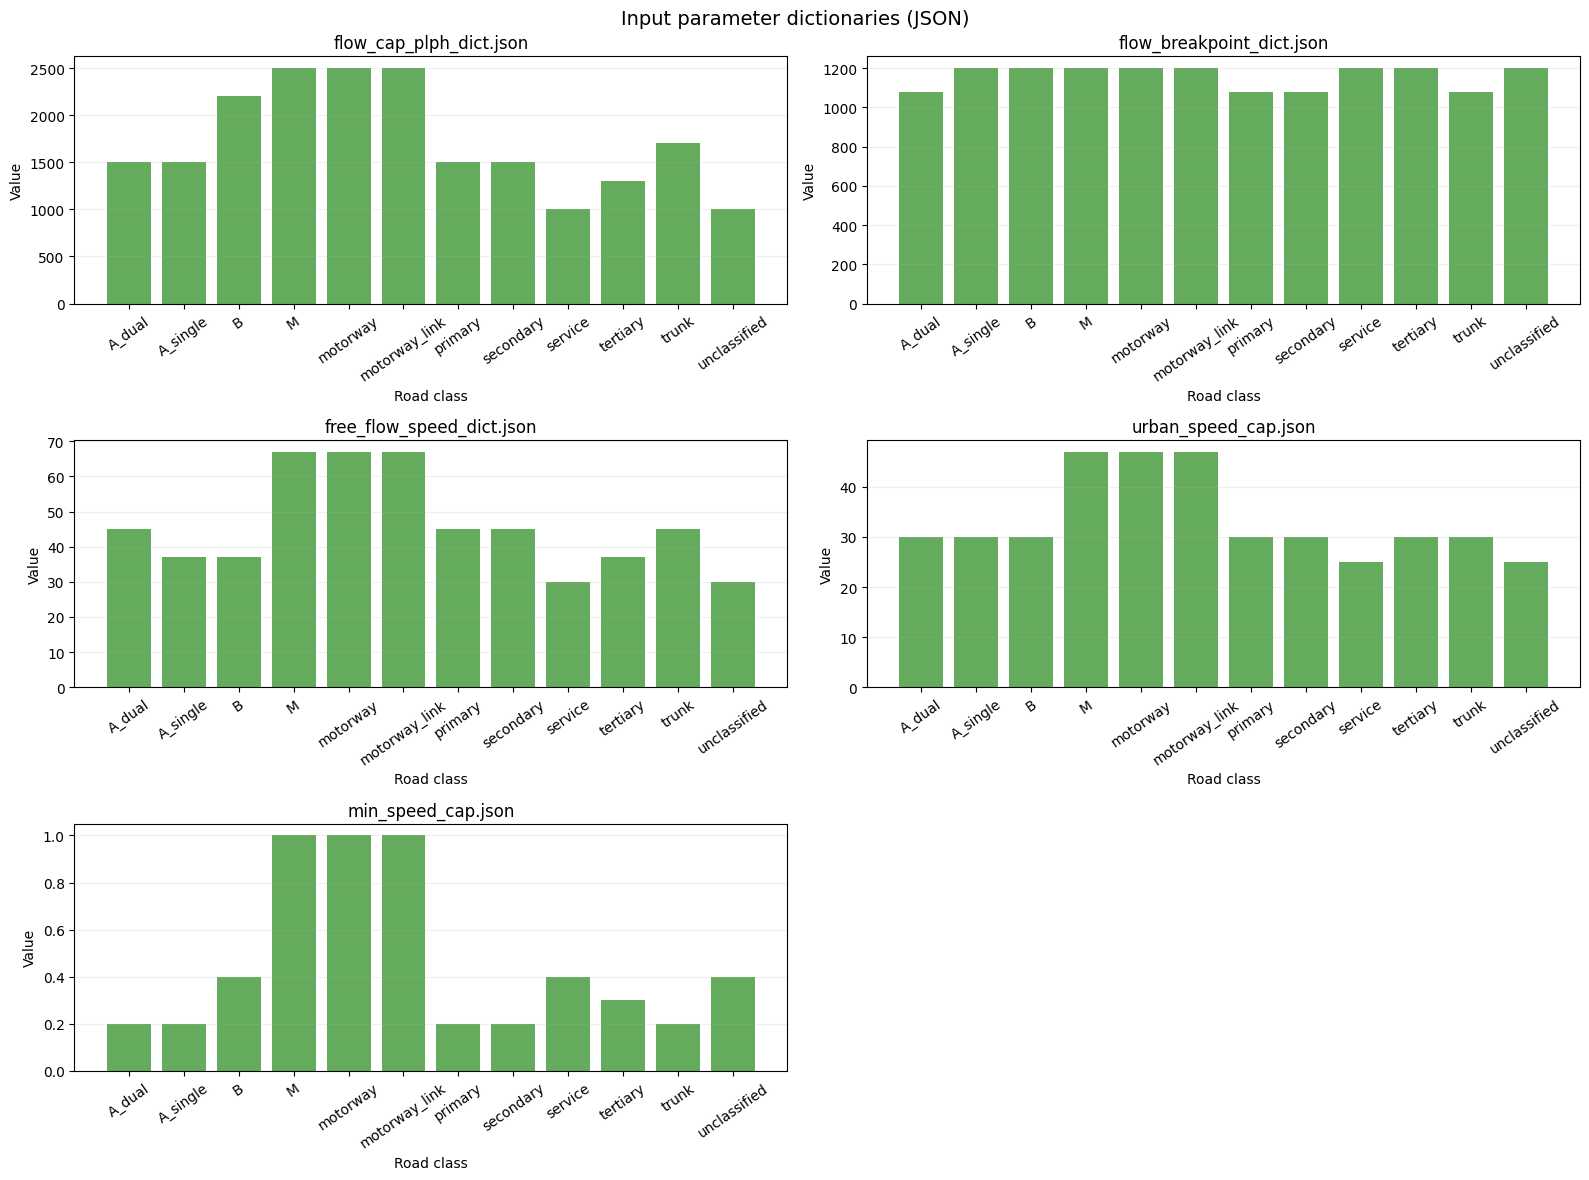

Parameter directory: C:\Users\alimu\NIRD_Data\va_soge_clusters_toy\parameters
Detected JSON files:
 - capt_extensive.json
 - capt_minor.json
 - capt_moderate.json
 - capt_severe.json
 - flow_breakpoint_dict.json
 - flow_cap_plph_dict.json
 - free_flow_speed_dict.json
 - min_speed_cap.json
 - urban_speed_cap.json


In [11]:
# Visual diagnostics for major input tables and parameter JSONs

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- path discovery ----------
if "root" not in globals():
    root = Path.cwd()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent

if "input_root" not in globals() or input_root is None:
    input_candidates = []
    if os.getenv("NIRD_INPUT_ROOT"):
        input_candidates.append(Path(os.getenv("NIRD_INPUT_ROOT")))
    input_candidates.extend([
        Path.home() / "NIRD_Data" / "va_soge_clusters_toy",
        Path.home() / "NIRD_Data" / "fairfax_soge_clusters_toy",
        root / "sandbox" / "fairfax_soge_clusters_toy",
        root / "sandbox" / "fairfax_baseline",
])
    input_root = _first_existing(input_candidates)
if input_root is None:
    raise FileNotFoundError("Could not find the notebook input root.")

base_input = input_root
step_inputs_fig_dir = fig_root / "step_inputs"
step_inputs_fig_dir.mkdir(parents=True, exist_ok=True)


def _load_json(path: Path):
    with open(path, "r") as f:
        return json.load(f)


def _to_numeric_dict(d):
    out = {}
    for k, v in d.items():
        if str(k).startswith("_"):
            continue
        try:
            out[str(k)] = float(v)
        except Exception:
            continue
    return out


# ---------- 1) Recovery design table ----------
recovery_path = _first_existing([
    base_input / "tables" / "recovery design_updated.csv",
    base_input / "inputs" / "tables" / "recovery design_updated.csv",
])

if recovery_path is not None:
    recovery_df = pd.read_csv(recovery_path)

    bridge_cols = [c for c in recovery_df.columns if c.startswith("bridge_")]
    road_cols = [c for c in recovery_df.columns if c.startswith("road_")]

    x_col = "event_day" if "event_day" in recovery_df.columns else "scenario"

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for c in bridge_cols:
        axes[0].plot(recovery_df[x_col], pd.to_numeric(recovery_df[c], errors="coerce"), marker="o", label=c.replace("bridge_", ""))
    axes[0].set_title("Bridge recovery rates")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel("Recovery factor")
    axes[0].grid(True, alpha=0.2)
    axes[0].legend(frameon=False, fontsize=8)

    for c in road_cols:
        axes[1].plot(recovery_df[x_col], pd.to_numeric(recovery_df[c], errors="coerce"), marker="o", label=c.replace("road_", ""))
    axes[1].set_title("Road recovery rates")
    axes[1].set_xlabel(x_col)
    axes[1].grid(True, alpha=0.2)
    axes[1].legend(frameon=False, fontsize=8)

    fig.suptitle(f"Input: recovery design table ({recovery_path.name})", fontsize=13)
    fig.tight_layout()
    save_figure(fig, step_inputs_fig_dir, "inputs_recovery_design")
    plt.show()
else:
    print("Recovery table not found.")


# ---------- 2) Damage ratio curve table ----------
ratio_path = _first_existing([
    base_input / "damage_curves" / "damage_ratio_road_flood.xlsx",
    base_input / "damage_curves" / "damage_ratio_road_flood.xlsx",
    base_input / "tables" / "damage_ratio_road_flood.xlsx",
    base_input / "tables" / "damage_ratio_road_flood.xlsx",
    base_input / "inputs" / "lookup" / "damage_ratio_road_flood_uk.xlsx",
    base_input / "inputs" / "lookup" / "damage_ratio_road_flood.xlsx",
    base_input / "damage_curves" / "damage_ratio_road_flood.csv",
    base_input / "damage_curves" / "damage_ratio_road_flood.csv",
])

if ratio_path is not None:
    if ratio_path.suffix.lower() == ".xlsx":
        ratio_df = pd.read_excel(ratio_path, sheet_name=0)
    else:
        ratio_df = pd.read_csv(ratio_path)

    ratio_df = ratio_df.copy()
    ratio_df.columns = [str(c).strip() for c in ratio_df.columns]
    x_col = "intensity" if "intensity" in ratio_df.columns else ratio_df.columns[0]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for c in ratio_df.columns:
        if c == x_col:
            continue
        y = pd.to_numeric(ratio_df[c], errors="coerce")
        if y.notna().sum() == 0:
            continue
        ax.plot(pd.to_numeric(ratio_df[x_col], errors="coerce"), y, marker="o", label=c)

    ax.set_title("Damage ratio curves by flood intensity")
    ax.set_xlabel(x_col)
    ax.set_ylabel("Damage ratio")
    ax.grid(True, alpha=0.2)
    ax.legend(frameon=False, fontsize=8, ncol=2)
    fig.suptitle(f"Input: damage ratio table ({ratio_path.name})", fontsize=13)
    fig.tight_layout()
    save_figure(fig, step_inputs_fig_dir, "inputs_damage_ratio_curves")
    plt.show()
else:
    print("Damage ratio table not found.")


# ---------- 3) Damage cost table ----------
cost_path = _first_existing([
    base_input / "asset_costs" / "damage_cost_road_flood.xlsx",
    base_input / "tables" / "damage_cost_road_flood.xlsx",
    base_input / "inputs" / "lookup" / "damage_cost_road_flood.xlsx",
    base_input / "asset_costs" / "damage_cost_road_flood_uk.csv",
])

if cost_path is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    if cost_path.suffix.lower() == ".xlsx":
        xls = pd.ExcelFile(cost_path)
        sheet_names = xls.sheet_names

        for ax_idx, sh in enumerate(sheet_names[:2]):
            d = pd.read_excel(cost_path, sheet_name=sh)
            d.columns = [str(c).strip() for c in d.columns]
            if not {"label", "Min", "Max", "Mean"}.issubset(d.columns):
                axes[ax_idx].text(0.5, 0.5, f"Unsupported columns in sheet '{sh}'", ha="center", va="center")
                axes[ax_idx].set_axis_off()
                continue

            dd = d.copy()
            dd["label"] = dd["label"].astype(str)
            dd["Min"] = pd.to_numeric(dd["Min"], errors="coerce")
            dd["Max"] = pd.to_numeric(dd["Max"], errors="coerce")
            dd["Mean"] = pd.to_numeric(dd["Mean"], errors="coerce")

            yerr_lower = (dd["Mean"] - dd["Min"]).clip(lower=0).to_numpy()
            yerr_upper = (dd["Max"] - dd["Mean"]).clip(lower=0).to_numpy()

            axes[ax_idx].bar(dd["label"], dd["Mean"], color="#4c78a8", alpha=0.9)
            axes[ax_idx].errorbar(
                dd["label"],
                dd["Mean"],
                yerr=np.vstack([yerr_lower, yerr_upper]),
                fmt="none",
                ecolor="#111827",
                elinewidth=1.2,
                capsize=4,
            )
            axes[ax_idx].set_title(f"{sh.capitalize()} asset damage cost assumptions")
            axes[ax_idx].set_xlabel("Class")
            axes[ax_idx].set_ylabel("Cost")
            axes[ax_idx].grid(True, axis="y", alpha=0.2)
            axes[ax_idx].tick_params(axis="x", rotation=20)
    else:
        d = pd.read_csv(cost_path)
        d.columns = [str(c).strip() for c in d.columns]
        if {"label", "Min", "Max", "Mean"}.issubset(d.columns):
            dd = d.copy()
            dd["label"] = dd["label"].astype(str)
            dd["Min"] = pd.to_numeric(dd["Min"], errors="coerce")
            dd["Max"] = pd.to_numeric(dd["Max"], errors="coerce")
            dd["Mean"] = pd.to_numeric(dd["Mean"], errors="coerce")
            yerr_lower = (dd["Mean"] - dd["Min"]).clip(lower=0).to_numpy()
            yerr_upper = (dd["Max"] - dd["Mean"]).clip(lower=0).to_numpy()
            axes[0].bar(dd["label"], dd["Mean"], color="#4c78a8", alpha=0.9)
            axes[0].errorbar(
                dd["label"], dd["Mean"], yerr=np.vstack([yerr_lower, yerr_upper]),
                fmt="none", ecolor="#111827", elinewidth=1.2, capsize=4
            )
            axes[0].set_title("Asset damage cost assumptions")
            axes[0].set_xlabel("Class")
            axes[0].set_ylabel("Cost")
            axes[0].grid(True, axis="y", alpha=0.2)
            axes[0].tick_params(axis="x", rotation=20)
            axes[1].set_axis_off()
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "Unsupported damage-cost CSV format", ha="center", va="center")
                ax.set_axis_off()

    fig.suptitle(f"Input: damage cost table ({cost_path.name})", fontsize=13)
    fig.tight_layout()
    save_figure(fig, step_inputs_fig_dir, "inputs_damage_cost_assumptions")
    plt.show()
else:
    print("Damage cost table not found.")


# ---------- 4) Parameter JSONs ----------
param_dir = _first_existing([
    base_input / "parameters",
    base_input / "inputs" / "parameters",
])

if param_dir is not None:
    json_paths = sorted(param_dir.glob("*.json"))

    # 4A) Captured capacity trajectories
    cap_files = [
        "capt_minor.json",
        "capt_moderate.json",
        "capt_extensive.json",
        "capt_severe.json",
    ]
    cap_series = {}
    for fn in cap_files:
        p = param_dir / fn
        if p.exists():
            obj = _load_json(p)
            if isinstance(obj, list):
                cap_series[fn.replace("capt_", "").replace(".json", "")] = pd.to_numeric(pd.Series(obj), errors="coerce")

    if cap_series:
        fig, ax = plt.subplots(figsize=(10, 5.5))
        for name, s in cap_series.items():
            ax.plot(np.arange(len(s)), s, label=name)
        ax.set_title("Recovery trajectory arrays from capt_*.json")
        ax.set_xlabel("Index (time step)")
        ax.set_ylabel("Recovery factor")
        ax.grid(True, alpha=0.2)
        ax.legend(frameon=False)
        fig.tight_layout()
        save_figure(fig, step_inputs_fig_dir, "inputs_parameters_capt_series")
        plt.show()

    # 4B) Dictionary-based parameter comparison
    dict_files = [
        "flow_cap_plph_dict.json",
        "flow_breakpoint_dict.json",
        "free_flow_speed_dict.json",
        "urban_speed_cap.json",
        "min_speed_cap.json",
    ]

    rows = []
    for fn in dict_files:
        p = param_dir / fn
        if not p.exists():
            continue
        obj = _load_json(p)
        if not isinstance(obj, dict):
            continue
        dd = _to_numeric_dict(obj)
        for k, v in dd.items():
            rows.append({"file": fn, "class": k, "value": v})

    if rows:
        param_df = pd.DataFrame(rows)

        fig, axes = plt.subplots(3, 2, figsize=(16, 12))
        axes = axes.flatten()

        for i, fn in enumerate([f for f in dict_files if (param_dir / f).exists()]):
            if i >= len(axes):
                break
            ax = axes[i]
            d = param_df[param_df["file"] == fn].copy().sort_values("class")
            ax.bar(d["class"], d["value"], color="#54a24b", alpha=0.9)
            ax.set_title(fn)
            ax.set_xlabel("Road class")
            ax.set_ylabel("Value")
            ax.grid(True, axis="y", alpha=0.2)
            ax.tick_params(axis="x", rotation=35)

        for j in range(i + 1, len(axes)):
            axes[j].set_axis_off()

        fig.suptitle("Input parameter dictionaries (JSON)", fontsize=14)
        fig.tight_layout()
        save_figure(fig, step_inputs_fig_dir, "inputs_parameters_dicts")
        plt.show()

    print(f"Parameter directory: {param_dir}")
    print("Detected JSON files:")
    for p in json_paths:
        print(" -", p.name)
else:
    print("Parameter directory not found.")